In [1]:
import scanpy as sc
import anndata as ad
import numpy as np
import pandas as pd

In [2]:
from scipy import sparse
from anndata import AnnData
from pandas.api.types import CategoricalDtype
from matplotlib import pylab
import warnings
import socket
import yaml
from sklearn.cluster import DBSCAN
import holoviews as hv
import scvelo as scv
import seaborn as sns
import os
import sys
import scanpy.external as sce
import matplotlib as plt
import igraph
from fa2_modified import ForceAtlas2
import leidenalg

In [3]:
sc.settings.verbosity = 3             # verbosity: errors (0), warnings (1), info (2), hints (3)
sc.logging.print_header()

scanpy==1.10.4 anndata==0.11.4 umap==0.5.7 numpy==2.2.6 scipy==1.15.2 pandas==2.2.3 scikit-learn==1.6.1 statsmodels==0.14.4 igraph==0.11.8 pynndescent==0.5.13


In [4]:
outdir="saved/scanpy/"
adata = sc.read_h5ad("/projects/viCO/saved/all_donor_annotated_05.h5ad")

In [5]:
adata

AnnData object with n_obs × n_vars = 33900 × 20733
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'donorId', 'percent.mt', 'percent.ribo', 'S.Score', 'G2M.Score', 'Phase', 'old.ident', 'batch', 'condition', 'donor', 'RNA_snn_res.0.5', 'seurat_clusters', 'sctype_pred'
    var: 'vf_vst_counts_mean', 'vf_vst_counts_variance', 'vf_vst_counts_variance.expected', 'vf_vst_counts_variance.standardized', 'vf_vst_counts_variable', 'vf_vst_counts_rank', 'var.features', 'var.features.rank'
    uns: 'neighbors'
    obsm: 'X_harmony', 'X_pca', 'X_umap'
    varm: 'HARMONY', 'PCs'
    obsp: 'distances'

In [6]:
#new column naming (Aurora)

## condition
mapping_condition = {
    "vasc_mg": "viCO",
    "vasc": "vCO",
    "ctr": "cCO",
}
adata.obs["condition"] = adata.obs["condition"].map(mapping_condition)
print(adata.obs["condition"].value_counts())

## donor
mapping_donor = {
    "Alz37cl2": "CL1",
    "Alz43cl2": "CL2",
    "PLCG1": "CL3",
}

adata.obs["donor"] = adata.obs["donor"].map(mapping_donor)
print(adata.obs["donor"].value_counts())

## orig.ident

print(adata.obs["orig.ident"].value_counts())
mapping_orig = {
    "Alz37cl2_ctr": "CL1_cCO",
    "Alz37cl2_vasc": "CL1_vCO",
    "Alz37cl2_vasc_mg": "CL1_viCO",
    "PLCG1_ctr": "CL3_cCO",
    "PLCG1_vasc": "CL3_vCO",
    "PLCG1_vasc_mg": "CL3_viCO",
    "Alz43cl2_ctr": "CL2_cCO",
    "Alz43cl2_vasc": "CL2_vCO",
    "Alz43cl2_vasc_mg": "CL2_viCO"
}

adata.obs["orig.ident"] = adata.obs["orig.ident"].map(mapping_orig)
print(adata.obs["orig.ident"].value_counts())




condition
viCO    13899
vCO     11254
cCO      8747
Name: count, dtype: int64
donor
CL1    12675
CL2    11151
CL3    10074
Name: count, dtype: int64
orig.ident
Alz37cl2_vasc_mg    5025
PLCG1_vasc_mg       4520
Alz43cl2_vasc_mg    4354
Alz43cl2_vasc       4223
Alz37cl2_vasc       3981
Alz37cl2_ctr        3669
PLCG1_vasc          3050
Alz43cl2_ctr        2574
PLCG1_ctr           2504
Name: count, dtype: int64
orig.ident
CL1_viCO    5025
CL3_viCO    4520
CL2_viCO    4354
CL2_vCO     4223
CL1_vCO     3981
CL1_cCO     3669
CL3_vCO     3050
CL2_cCO     2574
CL3_cCO     2504
Name: count, dtype: int64


In [7]:
adata.obs

,orig.ident,nCount_RNA,nFeature_RNA,donorId,percent.mt,percent.ribo,S.Score,G2M.Score,Phase,old.ident,batch,condition,donor,RNA_snn_res.0.5,seurat_clusters,sctype_pred
Alz37cl2_ctr_AAACCAAAGCGGTTCG-1,CL1_cCO,7030.0,3029,Alz37cl2_ctr,3.029872,10.469417,-0.014446,-0.200661,G1,0,B2,cCO,CL1,3,3,GABAergic neuron
Alz37cl2_ctr_AAACCAAAGGAACCAG-1,CL1_cCO,7817.0,3355,Alz37cl2_ctr,0.895484,8.136114,-0.144481,-0.173231,G1,0,B2,cCO,CL1,6,6,Immature neuron
Alz37cl2_ctr_AAACCCGCAACTTAGA-1,CL1_cCO,11610.0,4214,Alz37cl2_ctr,1.481481,11.851852,-0.174178,-0.153465,G1,0,B2,cCO,CL1,8,8,Radial glia
Alz37cl2_ctr_AAACCCGCAGGAATGA-1,CL1_cCO,9856.0,4096,Alz37cl2_ctr,0.162338,4.484578,-0.184625,-0.217560,G1,0,B2,cCO,CL1,0,0,Glutamatergic neuron
Alz37cl2_ctr_AAACCCGCATGAGCCA-1,CL1_cCO,10349.0,3978,Alz37cl2_ctr,0.357522,14.378201,0.262047,-0.131561,S,0,B2,cCO,CL1,8,8,Radial glia
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
PLCG1_vasc_mg_TGTGGTTGTATAGCAG-1,CL3_viCO,7305.0,3244,PLCG1_vasc_mg,2.026010,7.898700,-0.104656,-0.206554,G1,8,B1,viCO,CL3,0,0,Glutamatergic neuron
PLCG1_vasc_mg_TGTGGTTGTGATAGGC-1,CL3_viCO,8025.0,3615,PLCG1_vasc_mg,1.171340,13.071651,-0.101445,-0.169722,G1,8,B1,viCO,CL3,8,8,Radial glia
PLCG1_vasc_mg_TGTGTTAGTTAGTGTC-1,CL3_viCO,9284.0,3662,PLCG1_vasc_mg,1.486428,11.535976,-0.035968,-0.192658,G1,8,B1,viCO,CL3,0,0,Glutamatergic neuron
PLCG1_vasc_mg_TGTGTTAGTTCATCGG-1,CL3_viCO,6585.0,3223,PLCG1_vasc_mg,0.728929,4.434320,-0.133738,-0.226423,G1,8,B1,viCO,CL3,0,0,Glutamatergic neuron


In [8]:
adata.obsm["X_umap"]

array([[  0.21502303, -10.23008263],
       [  3.25518702,  -7.23526967],
       [ -2.73983194,   1.03998888],
       ...,
       [  5.33113669,  -6.93147719],
       [  6.06177949,  -3.79573119],
       [ -4.00254298,   0.48554146]], shape=(33900, 2))

In [9]:
dimredDir="saved/dimRed"

# Load the PCA embeddings (cells x PCs)
pca_emb = pd.read_csv(dimredDir+"pca_embeddings.csv", index_col=0)
# Load the PCA loadings (genes x PCs)
pca_load = pd.read_csv(dimredDir+"pca_loadings.csv", index_col=0)


# Load the PCA-corrected embeddings (cells x PCs)
har_emb = pd.read_csv(dimredDir+"harmony_embeddings.csv", index_col=0)
# Load the PCA-corrected loadings (genes x PCs)
har_load = pd.read_csv(dimredDir+"harmony_loadings.csv", index_col=0)


# Load the UMAP embeddings (cells x PCs)
umap_emb = pd.read_csv(dimredDir+"umap_embeddings.csv", index_col=0)


## loadings were not added because it's a subset of HVG and that creates a problem 

In [10]:
#Import highly variable genes
hvgenes = pd.read_csv(dimredDir+"scanpy/HVG.csv", index_col=0)


In [11]:
print(adata.X)

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 158987969 stored elements and shape (33900, 20733)>
  Coords	Values
  (0, 7)	1.0
  (0, 19)	1.0
  (0, 22)	1.0
  (0, 23)	1.0
  (0, 43)	1.0
  (0, 45)	1.0
  (0, 54)	1.0
  (0, 57)	2.0
  (0, 89)	1.0
  (0, 90)	1.0
  (0, 98)	10.0
  (0, 118)	3.0
  (0, 123)	9.0
  (0, 125)	2.0
  (0, 138)	1.0
  (0, 140)	2.0
  (0, 143)	1.0
  (0, 144)	3.0
  (0, 147)	1.0
  (0, 151)	1.0
  (0, 154)	1.0
  (0, 157)	1.0
  (0, 186)	1.0
  (0, 205)	1.0
  (0, 217)	1.0
  :	:
  (33899, 20669)	1.0
  (33899, 20673)	2.0
  (33899, 20684)	4.0
  (33899, 20687)	2.0
  (33899, 20688)	2.0
  (33899, 20694)	3.0
  (33899, 20695)	1.0
  (33899, 20697)	9.0
  (33899, 20698)	1.0
  (33899, 20705)	3.0
  (33899, 20708)	1.0
  (33899, 20712)	2.0
  (33899, 20714)	1.0
  (33899, 20715)	1.0
  (33899, 20716)	2.0
  (33899, 20717)	3.0
  (33899, 20718)	36.0
  (33899, 20719)	9.0
  (33899, 20721)	4.0
  (33899, 20722)	13.0
  (33899, 20723)	3.0
  (33899, 20724)	2.0
  (33899, 20725)	18.0
  (33899, 2072

In [12]:
adata.layers["counts"] = adata.X.copy()
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)
sc.pp.highly_variable_genes(adata, n_top_genes=2000)


normalizing counts per cell
    finished (0:00:00)
extracting highly variable genes
    finished (0:00:01)
--> added
    'highly_variable', boolean vector (adata.var)
    'means', float vector (adata.var)
    'dispersions', float vector (adata.var)
    'dispersions_norm', float vector (adata.var)


In [13]:
seurat_hvg_list = hvgenes['VariableFeatures'].tolist()

adata.var["highly_variable_seurat"] = adata.var.index.isin(seurat_hvg_list)


In [14]:
hvg_mask = adata.var['highly_variable_seurat']
hvg_genes = adata.var_names[hvg_mask]
assert all(gene in pca_load.index for gene in hvg_genes), "Mismatch in gene names!"


In [15]:
pca_load_aligned = pca_load.loc[hvg_genes]


In [16]:
n_genes = adata.shape[1]
n_pcs = pca_load.shape[1]

# Initialize empty matrix with NaNs
full_loadings = np.full((n_genes, n_pcs), np.nan)

# Insert actual loadings at the right positions
full_loadings[hvg_mask.values, :] = pca_load_aligned.values

# Store in adata.varm
adata.varm['pca_loadings'] = full_loadings

In [17]:
adata

AnnData object with n_obs × n_vars = 33900 × 20733
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'donorId', 'percent.mt', 'percent.ribo', 'S.Score', 'G2M.Score', 'Phase', 'old.ident', 'batch', 'condition', 'donor', 'RNA_snn_res.0.5', 'seurat_clusters', 'sctype_pred'
    var: 'vf_vst_counts_mean', 'vf_vst_counts_variance', 'vf_vst_counts_variance.expected', 'vf_vst_counts_variance.standardized', 'vf_vst_counts_variable', 'vf_vst_counts_rank', 'var.features', 'var.features.rank', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'highly_variable_seurat'
    uns: 'neighbors', 'log1p', 'hvg'
    obsm: 'X_harmony', 'X_pca', 'X_umap'
    varm: 'HARMONY', 'PCs', 'pca_loadings'
    layers: 'counts'
    obsp: 'distances'

In [18]:
# Align the cell order
pca_emb = pca_emb.loc[adata.obs_names]

# Add to AnnData
adata.obsm["X_pca"] = pca_emb.to_numpy()


In [19]:

har_emb = har_emb.loc[adata.obs_names]
umap_emb = umap_emb.loc[adata.obs_names]

adata.obsm["X_harmony"] = har_emb.to_numpy()
adata.obsm["X_umap"] = umap_emb.to_numpy()

In [20]:
#loadings from harmony
assert all(gene in har_load.index for gene in hvg_genes), "Mismatch in gene names!"
har_load_aligned = har_load.loc[hvg_genes]

n_genes = adata.shape[1]
n_pcs = har_load.shape[1]

In [21]:
# Initialize empty matrix with NaNs
full_loadings = np.full((n_genes, n_pcs), np.nan)

# Insert actual loadings at the right positions
full_loadings[hvg_mask.values, :] = har_load_aligned.values

# Store in adata.varm
adata.varm['harmony_loadings'] = full_loadings

In [22]:
adata.var

,vf_vst_counts_mean,vf_vst_counts_variance,vf_vst_counts_variance.expected,vf_vst_counts_variance.standardized,vf_vst_counts_variable,vf_vst_counts_rank,var.features,var.features.rank,highly_variable,means,dispersions,dispersions_norm,highly_variable_seurat
ENSG00000238009,0.006873,0.006885,0.007849,0.877183,0,-2147483648,NA,-2147483648,False,0.004458,-0.287428,-0.937058,False
ENSG00000241860,0.017257,0.017549,0.023005,0.762835,0,-2147483648,NA,-2147483648,False,0.011604,-0.197293,-0.714632,False
ENSG00000290385,0.013038,0.013400,0.016734,0.800761,0,-2147483648,NA,-2147483648,False,0.009027,-0.161127,-0.625384,False
ENSG00000291215,0.040619,0.041626,0.059971,0.694092,0,-2147483648,NA,-2147483648,False,0.028017,-0.142461,-0.579321,False
LINC01409,0.138643,0.197067,0.215743,0.913433,0,-2147483648,NA,-2147483648,False,0.087272,0.018172,-0.182925,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...
MT-CYB,29.458319,663.865722,540.500731,1.228242,0,-2147483648,NA,-2147483648,False,2.977291,2.057798,0.300886,False
ENSG00000276256,0.081357,0.095331,0.125526,0.759451,0,-2147483648,NA,-2147483648,False,0.063856,0.088767,-0.008715,False
ENSG00000273748,0.163776,0.237963,0.253684,0.938029,0,-2147483648,NA,-2147483648,False,0.109554,0.137119,0.110604,False
ENSG00000271254,0.247404,0.300717,0.388010,0.775025,0,-2147483648,NA,-2147483648,False,0.156923,-0.063354,-0.384107,False


In [23]:
pd.crosstab(adata.var['highly_variable'], adata.var['highly_variable_seurat'])

highly_variable_seurat,False,True
highly_variable,,
False,18394,339
True,339,1661


In [24]:
adata.obs["sctype_pred"].value_counts()

sctype_pred
Radial glia              9806
Roof plate progenitor    6033
Glutamatergic neuron     4978
Fibroblast               3001
GABAergic neuron         2836
Immature neuron          2064
Neuroblast               2039
ChP epithelial           1281
Smooth muscle             956
Microglia                 440
Schwann precursor         424
Endothelial                42
Name: count, dtype: int64

In [25]:
celltype_colors = {
    "Radial glia": "#e41a1c",
    "Roof plate progenitor": "#fa8841",
    "Glutamatergic neuron": "#7e6e85",
    "Fibroblast": "#e1c62f",
    "GABAergic neuron": "#b75f49",
    "Immature neuron": "#48a462",
    "Neuroblast": "#48d1cc",
    "ChP epithelial": "#4a72a6",
    "Smooth muscle": "#ec83ba",
    "Microglia": "#1a1a1a",
    "Schwann precursor ": "#6a3d9a",
    "Endothelial": "#1b9e77",    
}

In [26]:
adata.obs["sctype_pred"] = adata.obs["sctype_pred"].astype("category")

In [27]:
adata.uns["sctype_pred_colors"] = [celltype_colors[ct] for ct in adata.obs["sctype_pred"].cat.categories]

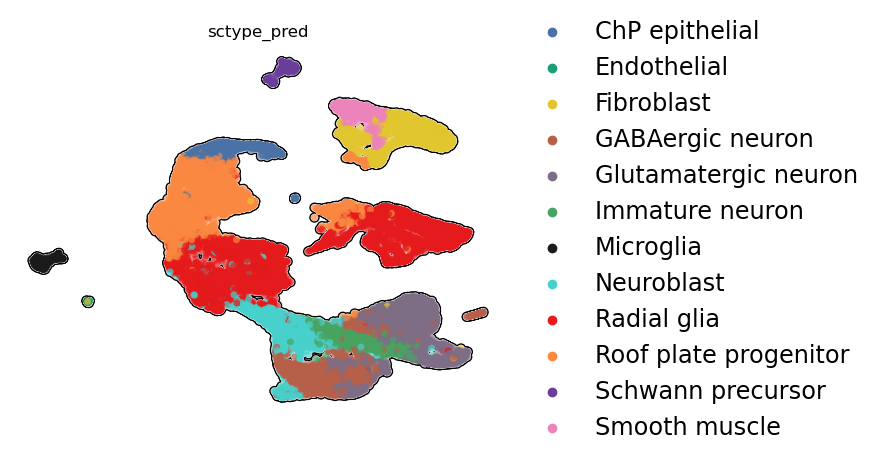

In [28]:
sc.pl.umap(adata, color=list(set(['sctype_pred'])), size = 100,add_outline=True, outline_width=(0.2, 0.05), vmin='p2',vmax='p98', wspace=.2, ncols=1, frameon=False, legend_fontsize="xx-large")

In [29]:
sc.pp.neighbors(adata, use_rep='X_harmony')

computing neighbors
    finished: added to `.uns['neighbors']`
    `.obsp['distances']`, distances for each pair of neighbors
    `.obsp['connectivities']`, weighted adjacency matrix (0:00:21)


In [30]:
sc.tl.draw_graph(adata)

drawing single-cell graph using layout 'fa'
    finished: added
    'X_draw_graph_fa', graph_drawing coordinates (adata.obsm) (0:04:57)


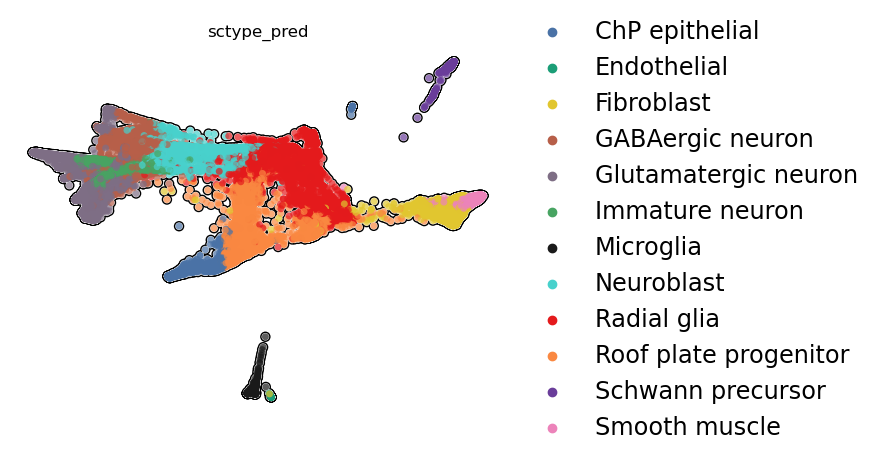

In [31]:
sc.pl.draw_graph(adata,color=["sctype_pred"], 
                 size = 100,add_outline=True, 
                 outline_width=(0.2, 0.05),
                 vmin='p2',vmax='p98', wspace=.2, ncols=1,
                 frameon=False, legend_fontsize="xx-large")

In [32]:
print("Taking the overall annotation")

Taking the overall annotation


In [33]:
sc.tl.paga(adata, groups="sctype_pred", use_rna_velocity=False)

groups="sctype_pred"
basis="X_draw_graph_fa"
if 'embeddings' in globals():
    del embeddings
for l in adata.obs[groups].cat.categories:
    test=adata.obsm[basis][adata.obs[groups] == l]
    x=np.mean(test[:,0])
    y=np.mean(test[:,1])
    if not 'embeddings' in globals():
        embeddings = np.array([x,y])
    else:
        embeddings=np.vstack([embeddings,np.array([x,y])])


running PAGA
    finished: added
    'paga/connectivities', connectivities adjacency (adata.uns)
    'paga/connectivities_tree', connectivities subtree (adata.uns) (0:00:00)


In [34]:
print("Taking subclustering")

Taking subclustering


running Leiden clustering
    finished: found 16 clusters and added
    'leiden_0.25', the cluster labels (adata.obs, categorical) (0:00:14)
running PAGA
    finished: added
    'paga/connectivities', connectivities adjacency (adata.uns)
    'paga/connectivities_tree', connectivities subtree (adata.uns) (0:00:00)


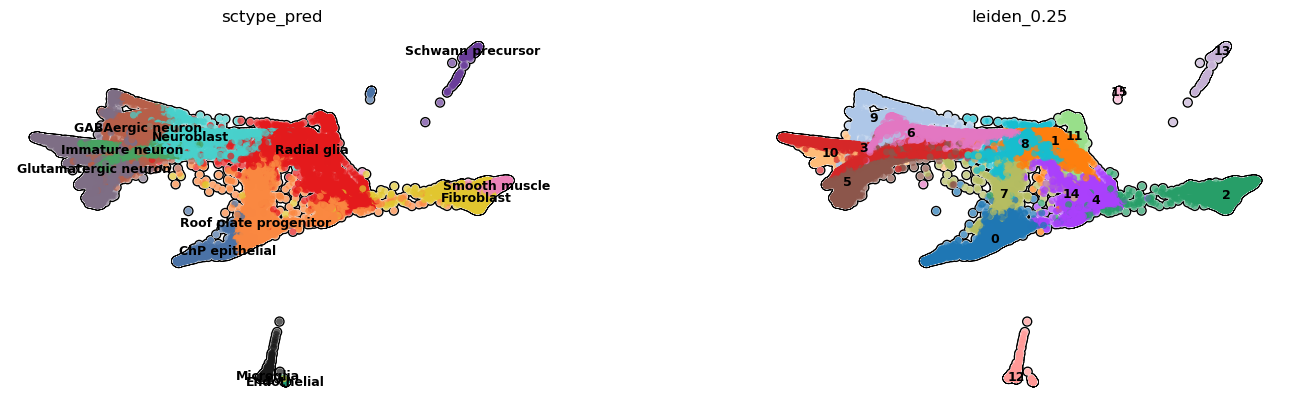

--> added 'pos', the PAGA positions (adata.uns['paga'])


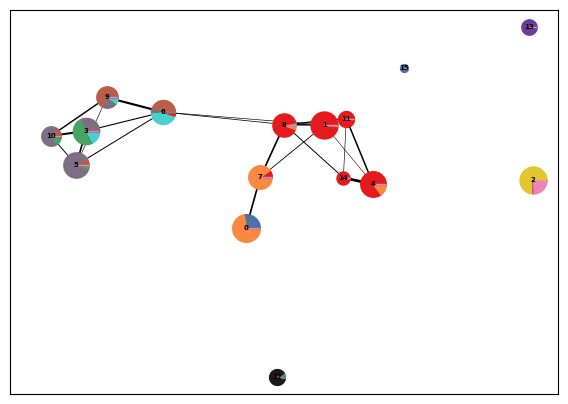

In [35]:
adataPaga = adata.copy()

leidenres = 0.25

sc.tl.leiden(adataPaga, resolution=leidenres, key_added="leiden_"+str(leidenres))

sc.tl.paga(adataPaga, groups="leiden_"+str(leidenres), use_rna_velocity=False)

groups="leiden_"+str(leidenres)
basis="X_draw_graph_fa"
if 'embeddings' in globals():
    del embeddings
for l in adataPaga.obs[groups].cat.categories:
    test=adataPaga.obsm[basis][adataPaga.obs[groups] == l]
    x=np.mean(test[:,0])
    y=np.mean(test[:,1])
    if not 'embeddings' in globals():
        embeddings = np.array([x,y])
    else:
        embeddings=np.vstack([embeddings,np.array([x,y])])

sc.pl.draw_graph(adataPaga, color = ["sctype_pred","leiden_"+str(leidenres)],ncols=2, 
           size = 100,add_outline=True, outline_width=(0.2, 0.05), vmin='p2',vmax='p98', legend_fontsize="9", frameon=False, wspace=.3, legend_loc="on data")

thresholdPagaEdges = 0.05

sc.settings.figdir = "saved/scanpy/figures"

sc.pl.paga(adataPaga, pos=embeddings, max_edge_width=2, threshold = thresholdPagaEdges, color = "sctype_pred", node_size_scale=2, fontsize=5, save="_paga_plot.pdf")

In [36]:
pd.crosstab(adataPaga.obs["sctype_pred"],adataPaga.obs["leiden_"+str(leidenres)]) / pd.crosstab(adataPaga.obs["sctype_pred"],adataPaga.obs["leiden_"+str(leidenres)]).sum(axis = 0)


leiden_0.25,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15
sctype_pred,,,,,,,,,,,,,,,,
ChP epithelial,0.276081,0.000000,0.000000,0.000000,0.000307,0.000000,0.000000,0.012777,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.0,1.0
Endothelial,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.086242,0.0,0.0,0.0
Fibroblast,0.000226,0.000000,0.745196,0.000280,0.000922,0.001271,0.000000,0.000000,0.000449,0.000000,0.001835,0.0,0.006160,0.0,0.0,0.0
GABAergic neuron,0.000000,0.000245,0.000000,0.020967,0.000000,0.105180,0.462430,0.000426,0.000449,0.696989,0.145872,0.0,0.000000,0.0,0.0,0.0
Glutamatergic neuron,0.000000,0.000000,0.000000,0.311155,0.000000,0.847474,0.048761,0.000000,0.000000,0.202008,0.691743,0.0,0.000000,0.0,0.0,0.0
Immature neuron,0.000000,0.000000,0.000000,0.495946,0.000000,0.035589,0.007994,0.000000,0.000000,0.003764,0.139450,0.0,0.000000,0.0,0.0,0.0
Microglia,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.903491,0.0,0.0,0.0
Neuroblast,0.000000,0.015456,0.000000,0.167738,0.000000,0.009851,0.433653,0.003407,0.040449,0.092221,0.013761,0.0,0.000000,0.0,0.0,0.0
Radial glia,0.000905,0.972522,0.000000,0.003634,0.851613,0.000318,0.046363,0.083901,0.900674,0.005019,0.007339,1.0,0.000000,0.0,1.0,0.0


In [37]:
import networkx as nx
testGraph = nx.from_numpy_array(adataPaga.uns["paga"]["connectivities"].todense(), parallel_edges=False, create_using=None )
testGraph.remove_edges_from([(n1, n2) for n1, n2, w in testGraph.edges(data="weight") if w < thresholdPagaEdges])
for t in testGraph.edges(data="weight"):
    testGraph[t[0]][t[1]]["weight"] = 1-t[2]

[4, 11, 1, 8, 6, 3, 10, 5]
sctype_pred                    ChP epithelial  Endothelial  Fibroblast  \
endpoint_Glutamatergic neuron                                            
0                                        1281           42        3001   
1                                           0            0           0   

sctype_pred                    GABAergic neuron  Glutamatergic neuron  \
endpoint_Glutamatergic neuron                                           
0                                          2836                   322   
1                                             0                  4656   

sctype_pred                    Immature neuron  Microglia  Neuroblast  \
endpoint_Glutamatergic neuron                                           
0                                            6        440         155   
1                                         2058          0        1884   

sctype_pred                    Radial glia  Roof plate progenitor  \
endpoint_Glutamatergi

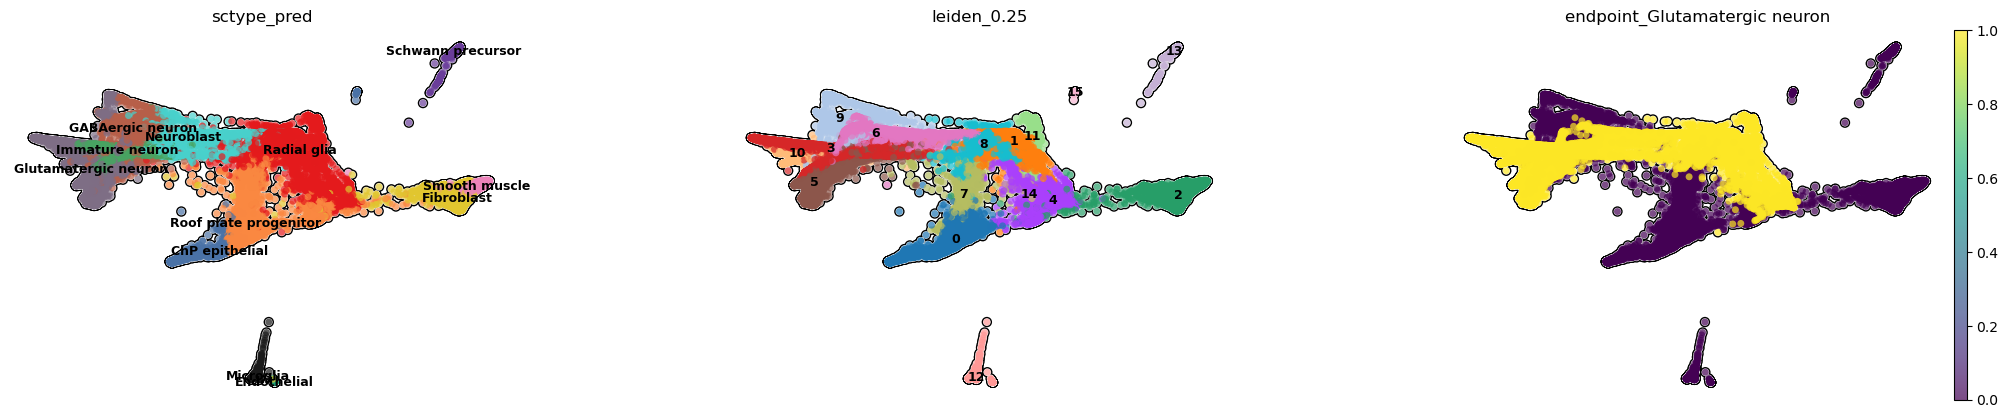

In [38]:
endpoint="Glutamatergic neuron"
sp = [4,11,1,8,6,3,10,5]

print(sp)
adataPaga.obs["endpoint_"+str(endpoint)] = adataPaga.obs["leiden_"+str(leidenres)].astype(int).isin(sp).astype(int)

keep_types = [
    "Glutamatergic neuron",
    "Immature neuron",
    "Neuroblast",
    "Radial glia"
]

mask = (adataPaga.obs["endpoint_"+str(endpoint)] == 1) & (adataPaga.obs["sctype_pred"].isin(keep_types))

adataPaga.obs["endpoint_"+str(endpoint)] = 0
adataPaga.obs.loc[mask, "endpoint_"+str(endpoint)] = 1

print(pd.crosstab(adataPaga.obs["endpoint_"+str(endpoint)], adataPaga.obs["sctype_pred"]))

sc.pl.draw_graph(adataPaga, color = ["sctype_pred","leiden_"+str(leidenres),"endpoint_"+str(endpoint)],ncols=3, 
                 size = 100,add_outline=True, outline_width=(0.2, 0.05), vmin='p2',vmax='p98',
                     legend_fontsize=9, frameon=False, wspace=.3, legend_loc="on data", save="_endpoint_neuroGluta_3cols.pdf")

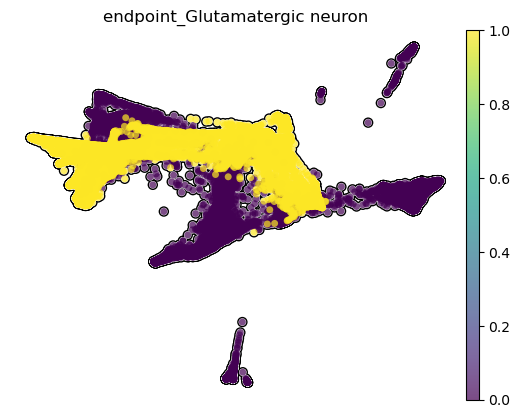

In [40]:
sc.pl.draw_graph(adataPaga, color = ["endpoint_Glutamatergic neuron"],
           size = 100,add_outline=True, outline_width=(0.2, 0.05), vmin='p2',vmax='p98', legend_fontsize="xx-large", 
                 frameon=False,  legend_loc="on data", save="_lineage_glutaNeurons.svg")

In [42]:
adataPaga.write_h5ad(filename="saved/scanpy/all_donor_annotated_05_wPaga.h5ad")